# Generate Report Figures
Reads FYRP Output Comparision Table.xlsx and creates 7 blue-themed figures

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [6]:
xls = pd.ExcelFile('FYRP Output Comparision Table.xlsx')
df = pd.read_excel(xls, sheet_name='rf')
print(f"Columns: {list(df.columns)}")
print(f"Shape: {df.shape}")
df.head(3)

Columns: ['Model Variant', 'Kernel', 'Dataset', 'Accuracy (Acc)', 'Precision (Prec)', 'Recall (Rec)', 'F1-Score', 'Specificity (Spec)', 'AUC-ROC']
Shape: (76, 9)


,Model Variant,Kernel,Dataset,Accuracy (Acc),Precision (Prec),Recall (Rec),F1-Score,Specificity (Spec),AUC-ROC
0,Random Forest,Entropy,Increased Size,0.975,1,0.95,0.9744,1,0.9962
1,Random Forest,Gini,Increased Size,0.975,1,0.95,0.9744,1,0.9956
2,Random Forest,Entropy,Balanced,0.972,1,0.9437,0.971,1,0.9986


In [7]:
# helper: get rows for a model + dataset combination
def get_best(df, model, dataset, metric='Accuracy (Acc)'):
    mask = df['Model Variant'].astype(str).str.contains(model, case=False, na=False)
    # Try matching by 'Dataset' column first
    ds_mask = df['Dataset'].astype(str).str.contains(dataset, case=False, na=False)
    rows = df[mask & ds_mask]
    if rows.empty:
        return None
    return rows[metric].max()

# Better: separate raw/balanced/increased/tuned data vs split data
# Rows with 'Dataset' values like Raw/Balanced/Increased/Tuned
cond_df = df[df['Dataset'].isin(['Raw', 'Balanced', 'Increased Size', 'Tuned','Increased Size'])]
# Rows with split values in Dataset column
split_df = df[df['Dataset'].isin(['90/10', '80/20', '70/30', '60/40'])]
print(f"Condition rows: {len(cond_df)}")
print(f"Split rows: {len(split_df)}")
cond_df['Dataset'].value_counts()

Condition rows: 28
Split rows: 36


Dataset
Increased Size    7
Balanced          7
Tuned             7
Raw               7
Name: count, dtype: int64

In [8]:
datasets = ['Raw', 'Balanced', 'Increased Size', 'Tuned']
kernels = ['Linear', 'Polynomial', 'RBF']
splits = ['90/10', '80/20', '70/30', '60/40']
models = ['Random Forest', 'SVM', 'SE', 'XGB']
model_labels = ['RF', 'SVM', 'SE', 'XGB+RF+SVM']
ds_labels = ['Raw', 'Balanced', 'Increased', 'Tuned']

## Fig 4.1: SVM Best Accuracy by Kernel

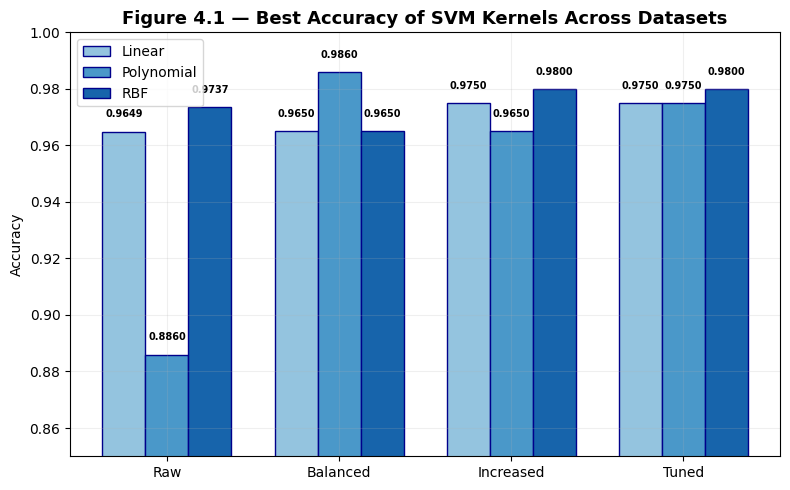

[OK] Figure 4.1 saved


In [9]:
svm_data = {}
for kernel in kernels:
    vals = []
    for ds in datasets:
        m = (cond_df['Model Variant'].astype(str).str.contains('SVM', case=False)) & \
            (cond_df['Kernel'].astype(str).str.contains(kernel, case=False)) & \
            (cond_df['Dataset'].astype(str).str.contains(ds, case=False))
        v = cond_df[m]['Accuracy (Acc)'].max() if m.any() else 0
        vals.append(v)
    svm_data[kernel] = vals

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(ds_labels)); w = 0.25
colors = plt.cm.Blues([0.4, 0.6, 0.8])
for i, (k, vals) in enumerate(svm_data.items()):
    bars = ax.bar(x + i*w, vals, w, label=k, color=colors[i], edgecolor='darkblue')
    for b, v in zip(bars, vals):
        if v: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{v:.4f}', ha='center', fontsize=7, fontweight='bold')
ax.set_xticks(x + w); ax.set_xticklabels(ds_labels)
ax.set_ylabel('Accuracy'); ax.set_ylim(0.85, 1.0)
ax.set_title('Figure 4.1 \u2014 Best Accuracy of SVM Kernels Across Datasets', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.2); plt.tight_layout()
plt.savefig('figures/fig4_1_svm_kernel_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()
print('[OK] Figure 4.1 saved')

## Fig 4.2: SVM Best Accuracy by Split

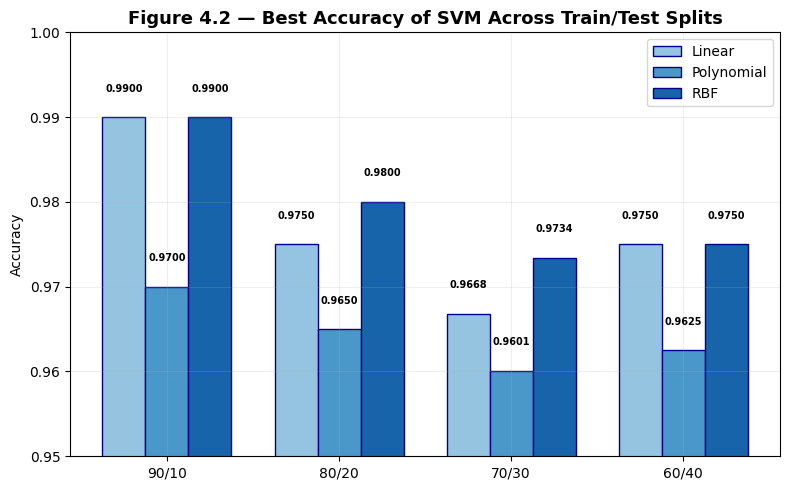

[OK] Figure 4.2 saved


In [10]:
svm_split = {}
for kernel in kernels:
    vals = []
    for sp in splits:
        m = (df['Model Variant'].astype(str).str.contains('SVM', case=False)) & \
            (df['Kernel'].astype(str).str.contains(kernel, case=False)) & \
            (df['Dataset'].astype(str).str.contains(sp, na=False))
        v = df[m]['Accuracy (Acc)'].max() if m.any() else 0
        vals.append(v)
    svm_split[kernel] = vals

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(splits))
for i, (k, vals) in enumerate(svm_split.items()):
    bars = ax.bar(x + i*w, vals, w, label=k, color=colors[i], edgecolor='darkblue')
    for b, v in zip(bars, vals):
        if v: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f'{v:.4f}', ha='center', fontsize=7, fontweight='bold')
ax.set_xticks(x + w); ax.set_xticklabels(splits)
ax.set_ylabel('Accuracy'); ax.set_ylim(0.95, 1.0)
ax.set_title('Figure 4.2 \u2014 Best Accuracy of SVM Across Train/Test Splits', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.2); plt.tight_layout()
plt.savefig('figures/fig4_2_svm_split_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()
print('[OK] Figure 4.2 saved')

## Fig 4.3-4.7: Multi-model comparisons

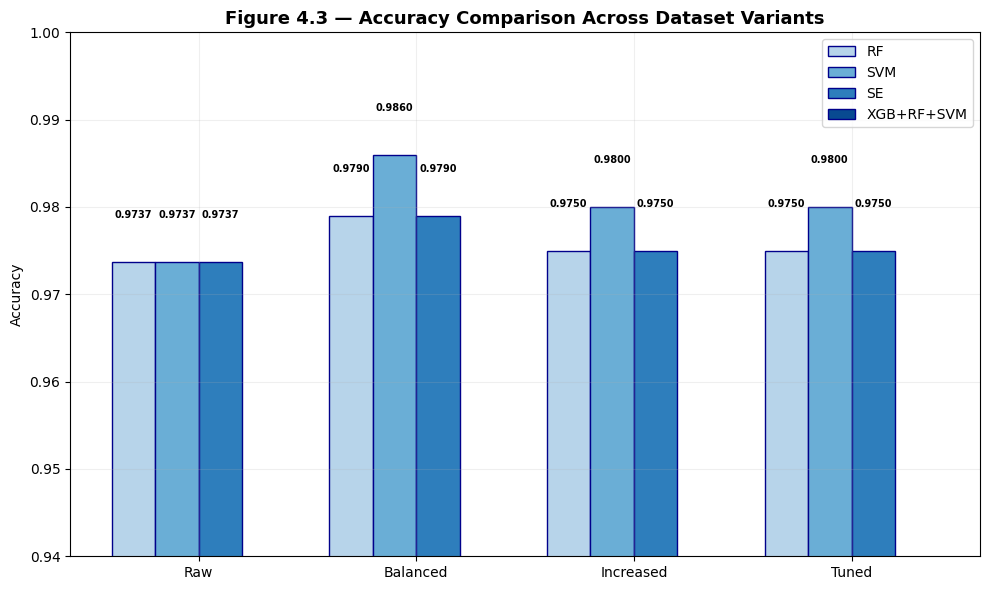

[OK] fig4_3_accuracy_comparison saved


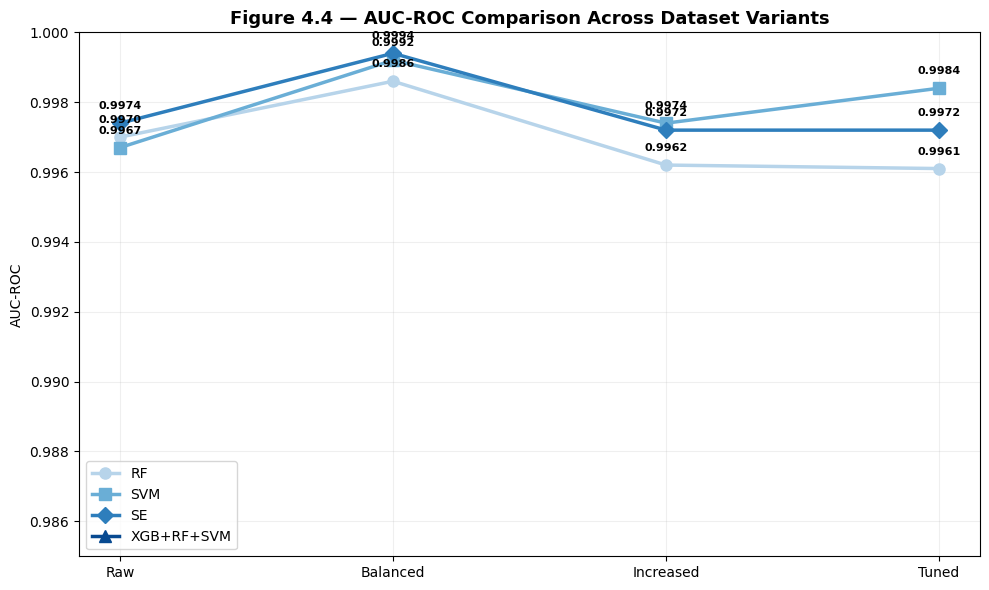

[OK] fig4_4_auc_comparison saved


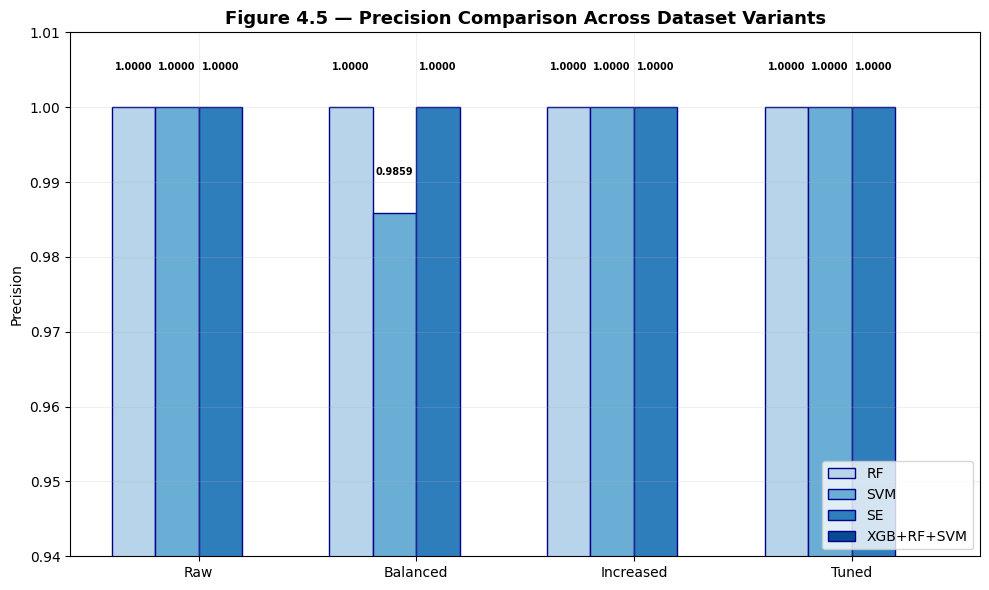

[OK] fig4_5_precision_comparison saved


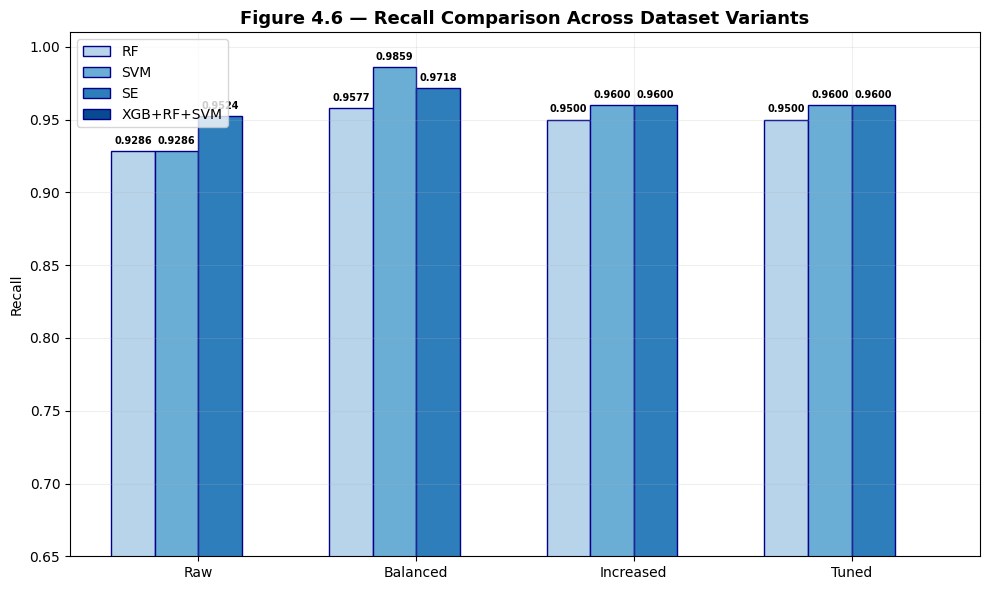

[OK] fig4_6_recall_comparison saved


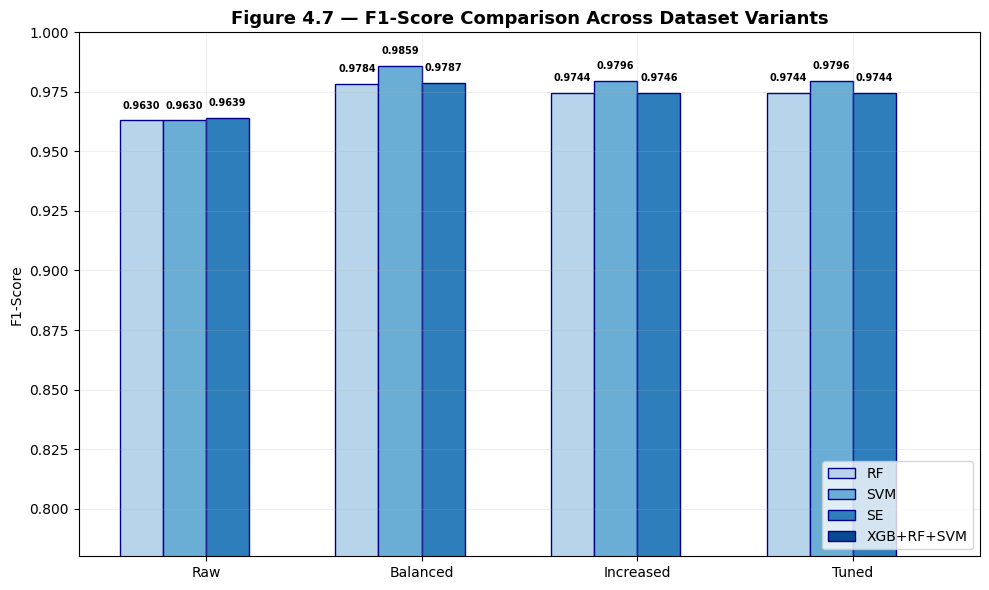

[OK] fig4_7_f1_comparison saved


In [11]:
def get_val(cond_df, model, ds, metric='Accuracy (Acc)'):
    m = (cond_df['Model Variant'].astype(str).str.contains(model, case=False)) & \
        (cond_df['Dataset'].str.contains(ds, case=False, na=False))
    if not m.any():
        return 0
    return cond_df[m][metric].max()

metrics_list = ['Accuracy (Acc)', 'AUC-ROC', 'Precision (Prec)', 'Recall (Rec)', 'F1-Score']
titles = ['Figure 4.3 \u2014 Accuracy Comparison', 'Figure 4.4 \u2014 AUC-ROC Comparison',
          'Figure 4.5 \u2014 Precision Comparison', 'Figure 4.6 \u2014 Recall Comparison',
          'Figure 4.7 \u2014 F1-Score Comparison']
filenames = ['fig4_3_accuracy_comparison', 'fig4_4_auc_comparison', 'fig4_5_precision_comparison',
             'fig4_6_recall_comparison', 'fig4_7_f1_comparison']
ylims = [(0.94, 1.0), (0.985, 1.0), (0.94, 1.01), (0.65, 1.01), (0.78, 1.0)]

for mi, metric in enumerate(metrics_list):
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(ds_labels)); w = 0.2
    colors2 = plt.cm.Blues([0.3, 0.5, 0.7, 0.9])
    
    for i, model in enumerate(models):
        vals = [get_val(cond_df, model, ds, metric) for ds in datasets]
        
        if 'AUC' in metric:
            # line chart for AUC
            markers = ['o', 's', 'D', '^']
            ax.plot(ds_labels, vals, marker=markers[i], label=model_labels[i],
                    color=colors2[i], linewidth=2.5, markersize=8)
            for j, v in enumerate(vals):
                ax.annotate(f'{v:.4f}', (ds_labels[j], v), textcoords='offset points',
                           xytext=(0, 10), ha='center', fontsize=8, fontweight='bold')
        else:
            bars = ax.bar(x + i*w, vals, w, label=model_labels[i], color=colors2[i], edgecolor='darkblue')
            for b, v in zip(bars, vals):
                if v: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{v:.4f}',
                            ha='center', fontsize=7, fontweight='bold')
            ax.set_xticks(x + 1.5*w)
            ax.set_xticklabels(ds_labels)
    
    if 'AUC' not in metric:
        ax.set_xticks(x + 1.5*w)
        ax.set_xticklabels(ds_labels)
    
    ax.set_ylabel(metric.split('(')[0].strip() if '(' in metric else metric)
    ax.set_ylim(ylims[mi])
    ax.set_title(f'{titles[mi]} Across Dataset Variants', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(f'figures/{filenames[mi]}.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f'[OK] {filenames[mi]} saved')

All 7 figures saved in the `figures/` folder. Insert them into your report at the corresponding sections.